# Прогнозирование оттока клиентов телеком-оператора

Проект посвящен прогнозированию оттока клиентов телеком-оператора на основе данных о договорах, подключенных услугах и характеристиках клиентов. Модель должна помочь заранее выявлять абонентов с повышенным риском ухода и использовать эту информацию для формирования удерживающих предложений.

**Цель проекта:**

* провести исследовательский анализ и подготовку данных;
* объединить информацию из нескольких таблиц базы данных;
* обучить несколько моделей классификации и выбрать лучшую по метрике ROC-AUC;
* оценить качество модели на тестовой выборке;
* проанализировать наиболее важные признаки, влияющие на отток клиентов, и сформулировать рекомендации для бизнеса.

Данные представлены в виде базы SQLite (`ds-plus-final.db`) с четырьмя таблицами: сведения о договоре (contract), персональные данные клиентов (personal), интернет-услуги (internet) и телефония (phone).

## 1. Загрузка данных

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, RocCurveDisplay,
)
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

RANDOM_STATE = 220626

Источник данных: учебный набор данных для задачи прогнозирования оттока клиентов телеком-оператора. Исходные данные не размещены в репозитории.

In [ ]:
path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

In [3]:
query = "SELECT name FROM sqlite_master WHERE type='table'"
all_tables = pd.read_sql(query, engine)
print(all_tables)

              name
0         data_arc
1        data_bulk
2   data_bulk_time
3   data_wire_time
4         contract
5         personal
6            phone
7         internet
8         data_gas
9        data_temp
10       data_wire


Проверим структуру всех таблиц, их размеры, типы данных, наличие пропусков и дубликатов. Это позволит убедиться, что данные корректно загрузились и определить, какие преобразования понадобятся на этапе предобработки.

In [4]:
contract = pd.read_sql('SELECT * FROM contract', engine)
personal = pd.read_sql('SELECT * FROM personal', engine)
internet = pd.read_sql('SELECT * FROM internet', engine)
phone = pd.read_sql('SELECT * FROM phone', engine)

for name, df in zip(['contract', 'personal', 'internet', 'phone'], [contract, personal, internet, phone]):
    print(name, df.shape)

contract (7043, 8)
personal (7043, 5)
internet (5517, 8)
phone (6361, 2)


**Вывод** 

Все таблицы успешно загружены. Полных дубликатов и явных пропусков не обнаружено, однако признаки имеют строковый тип данных и требуют дальнейшего преобразования.

## 2. Исследовательский анализ и предобработка исходных таблиц

### 2.1 Таблица contract

In [5]:
contract.info()
display(contract.head())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7043 non-null   str  
 1   BeginDate         7043 non-null   str  
 2   EndDate           7043 non-null   str  
 3   Type              7043 non-null   str  
 4   PaperlessBilling  7043 non-null   str  
 5   PaymentMethod     7043 non-null   str  
 6   MonthlyCharges    7043 non-null   str  
 7   TotalCharges      7043 non-null   str  
dtypes: str(8)
memory usage: 440.3 KB


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


In [6]:
contract.describe(include='all')

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
count,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,77,67,3,2,4,1585,6658
top,7590-VHVEG,2014-02-01,No,Month-to-month,Yes,Electronic check,20.05,
freq,1,366,5942,3875,4171,2365,61,11


Все столбцы загрузились как `object` (текст), хотя `MonthlyCharges` и `TotalCharges` должны быть числовыми, а `BeginDate`/`EndDate` - датами. Проверим аномалии перед преобразованием типов.

In [7]:
print('Пустые строки в TotalCharges:', (contract['TotalCharges'].str.strip() == '').sum())
contract.loc[contract['TotalCharges'].str.strip() == '', ['customerID', 'BeginDate', 'EndDate', 'MonthlyCharges', 'TotalCharges']]

Пустые строки в TotalCharges: 11


,customerID,BeginDate,EndDate,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,52.55,
753,3115-CZMZD,2020-02-01,No,20.25,
936,5709-LVOEQ,2020-02-01,No,80.85,
1082,4367-NUYAO,2020-02-01,No,25.75,
1340,1371-DWPAZ,2020-02-01,No,56.05,
3331,7644-OMVMY,2020-02-01,No,19.85,
3826,3213-VVOLG,2020-02-01,No,25.35,
4380,2520-SGTTA,2020-02-01,No,20.0,
5218,2923-ARZLG,2020-02-01,No,19.7,
6670,4075-WKNIU,2020-02-01,No,73.35,


У 11 клиентов `TotalCharges` - пустая строка. Все они заключили договор ровно в дату выгрузки данных (`2020-02-01`), то есть ещё не получили ни одного счёта - это не пропуск, а корректный «нулевой» расход. Заменим пустые строки на 0.

In [8]:
contract['TotalCharges'] = contract['TotalCharges'].str.strip().replace('', '0').astype(float)
contract['MonthlyCharges'] = contract['MonthlyCharges'].astype(float)
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

# EndDate = 'No' for customers who are still active — keep the original column as is
contract['Churn'] = (contract['EndDate'] != 'No').astype(int)
print(contract['Churn'].value_counts(normalize=True).round(3))

Churn
0    0.844
1    0.156
Name: proportion, dtype: float64


Подготовим таблицу договоров к дальнейшему анализу: приведем признаки к корректным типам данных, сформируем целевой признак и создадим новый признак, отражающий длительность действия договора.

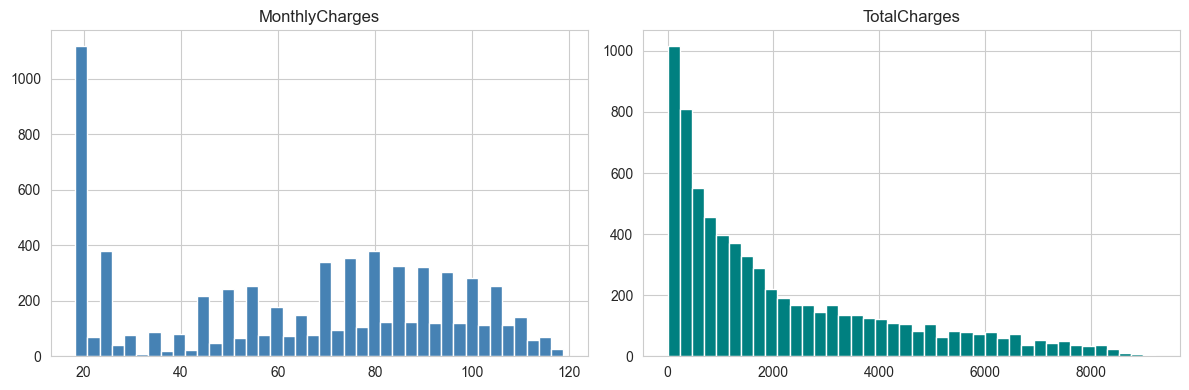

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
contract['MonthlyCharges'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('MonthlyCharges')
contract['TotalCharges'].hist(bins=40, ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('TotalCharges')
plt.tight_layout()
plt.show()

In [10]:
print('Диапазон дат заключения договора:', contract['BeginDate'].min().date(), '-', contract['BeginDate'].max().date())
contract['Type'].value_counts()

Диапазон дат заключения договора: 2013-10-01 - 2020-02-01


Type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

**Вывод** 

На данном этапе созданы целевой признак и длительность контракта, а числовые признаки приведены к корректному формату. Пропуски в TotalCharges заполнены нулевыми значениями, что соответствует новым клиентам без истории платежей.

### 2.2 Таблица personal

In [11]:
personal.info()
display(personal.head())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   str  
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: str(5)
memory usage: 275.2 KB


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [12]:
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents']:
    print(col, personal[col].unique())

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen <StringArray>
['0', '1']
Length: 2, dtype: str
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [13]:
personal['SeniorCitizen'] = personal['SeniorCitizen'].astype(int)
personal.duplicated(subset='customerID').sum()

np.int64(0)

Пропусков и аномалий нет, во всех категориальных столбцах ожидаемые значения (`Yes`/`No`, `Male`/`Female`). `SeniorCitizen` приведён к числовому типу (0/1), дубликатов по `customerID` нет.

### 2.3 Таблица internet

In [14]:
internet.info()
display(internet.head())

<class 'pandas.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5517 non-null   str  
 1   InternetService   5517 non-null   str  
 2   OnlineSecurity    5517 non-null   str  
 3   OnlineBackup      5517 non-null   str  
 4   DeviceProtection  5517 non-null   str  
 5   TechSupport       5517 non-null   str  
 6   StreamingTV       5517 non-null   str  
 7   StreamingMovies   5517 non-null   str  
dtypes: str(8)
memory usage: 344.9 KB


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [15]:
for col in internet.columns.drop('customerID'):
    print(col, internet[col].unique())

InternetService <StringArray>
['DSL', 'Fiber optic']
Length: 2, dtype: str
OnlineSecurity <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup <StringArray>
['Yes', 'No']
Length: 2, dtype: str
DeviceProtection <StringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies <StringArray>
['No', 'Yes']
Length: 2, dtype: str


Пропусков внутри таблицы нет - все клиенты, подключившие интернет, заполнили все услуги (`Yes`/`No`). Сама неполнота таблицы (5517 из 7043 клиентов) - это признак того, что интернет не подключён, а не ошибка в данных; обработаем это на этапе объединения таблиц.

### 2.4 Таблица phone

In [16]:
phone.info()
display(phone.head())

<class 'pandas.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerId     6361 non-null   str  
 1   MultipleLines  6361 non-null   str  
dtypes: str(2)
memory usage: 99.5 KB


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [17]:
print(phone['MultipleLines'].unique())
phone.columns

<StringArray>
['No', 'Yes']
Length: 2, dtype: str


Index(['CustomerId', 'MultipleLines'], dtype='str')

In [18]:
phone = phone.rename(columns={'CustomerId': 'customerID'})

Аномалий нет, услуга телефонии (как и интернет) подключена не у всех клиентов (6361 из 7043) - отсутствие строки означает отсутствие услуги.

## 3. Объединение таблиц и генерация признаков

In [19]:
df = contract.merge(personal, on='customerID', how='left') \
             .merge(internet, on='customerID', how='left') \
             .merge(phone, on='customerID', how='left')

print(df.shape)
df.head()

(7043, 21)


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04,0,Female,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84,0,Male,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17,0,Male,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.60,0,Male,...,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.50,0,Female,...,No,No,Fiber optic,No,No,No,No,No,No,No


Используем `contract` как базовую таблицу (по условию задачи каждому клиенту соответствует один договор) и присоединяем остальные таблицы через `left join`, чтобы сохранить всех 7043 клиентов. После объединения у клиентов без интернета/телефонии в соответствующих столбцах появятся пропуски - заменим их на значение `'No service'`, означающее отсутствие услуги (а не пропуск данных).

In [20]:
service_cols_internet = internet.columns.drop('customerID').tolist()
service_cols_phone = phone.columns.drop('customerID').tolist()
service_cols = service_cols_internet + service_cols_phone

print('Пропуски по услугам до обработки:')
print(df[service_cols].isna().sum())

df[service_cols] = df[service_cols].fillna('No service')

Пропуски по услугам до обработки:
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64


**Генерация новых признаков.**
- `ContractDuration` - длительность контракта в днях: для ушедших клиентов это `EndDate - BeginDate`, для действующих - `2020-02-01 - BeginDate` (дата выгрузки данных).
- `NumInternetServices` - количество подключённых интернет-услуг безопасности и развлечений (от 0 до 6).
- `HasInternet`, `HasPhone` - флаги подключения интернета и телефонии.

In [21]:
SNAPSHOT_DATE = pd.Timestamp('2020-02-01')

end_date = pd.to_datetime(df['EndDate'].where(df['EndDate'] != 'No', None))
end_date = end_date.fillna(SNAPSHOT_DATE)
df['ContractDuration'] = (end_date - df['BeginDate']).dt.days

df['HasInternet'] = (df['InternetService'] != 'No service').astype(int)
df['HasPhone'] = (df['MultipleLines'] != 'No service').astype(int)

internet_extra_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumInternetServices'] = (df[internet_extra_cols] == 'Yes').sum(axis=1)

df[['ContractDuration', 'HasInternet', 'HasPhone', 'NumInternetServices']].describe()

,ContractDuration,HasInternet,HasPhone,NumInternetServices
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,898.555729,0.783331,0.903166,2.037910
std,683.130510,0.412004,0.295752,1.847682
min,0.000000,0.000000,0.000000,0.000000
25%,276.000000,1.000000,1.000000,0.000000
50%,761.000000,1.000000,1.000000,2.000000
75%,1461.000000,1.000000,1.000000,3.000000
max,2314.000000,1.000000,1.000000,6.000000


In [22]:
print('Отрицательная длительность контракта:', (df['ContractDuration'] < 0).sum())
df[df['ContractDuration'] < 0]

Отрицательная длительность контракта: 0


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,ContractDuration,HasInternet,HasPhone,NumInternetServices


Отрицательных значений длительности контракта нет - аномалий в новом признаке не возникло.

In [23]:
df.duplicated(subset='customerID').sum()

np.int64(0)

**Вывод** 

Все данные успешно объединены. Каждому клиенту соответствует одна запись, содержащая информацию о договоре, персональных данных и подключенных услугах.

## 4. Исследовательский анализ объединённой таблицы

In [24]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

Пропусков в объединённой таблице не осталось.

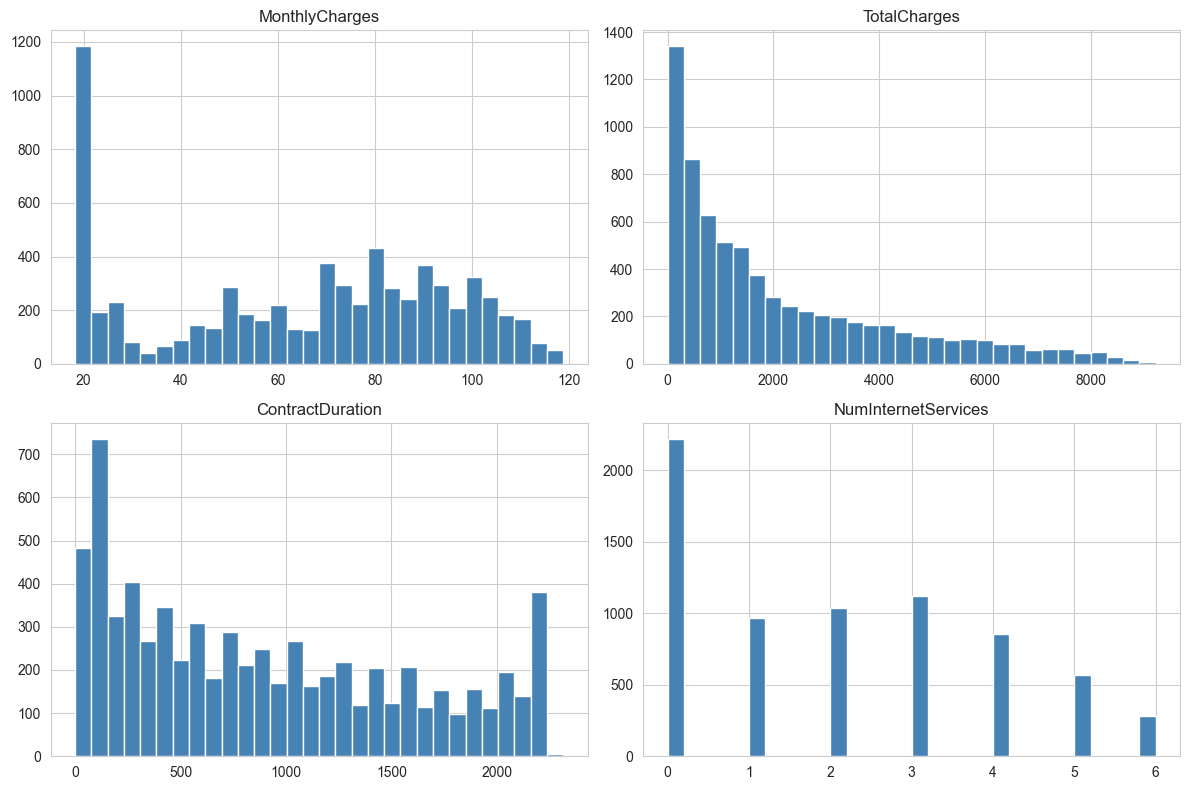

In [25]:
num_cols = ['MonthlyCharges', 'TotalCharges', 'ContractDuration', 'NumInternetServices']
cat_cols = ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()

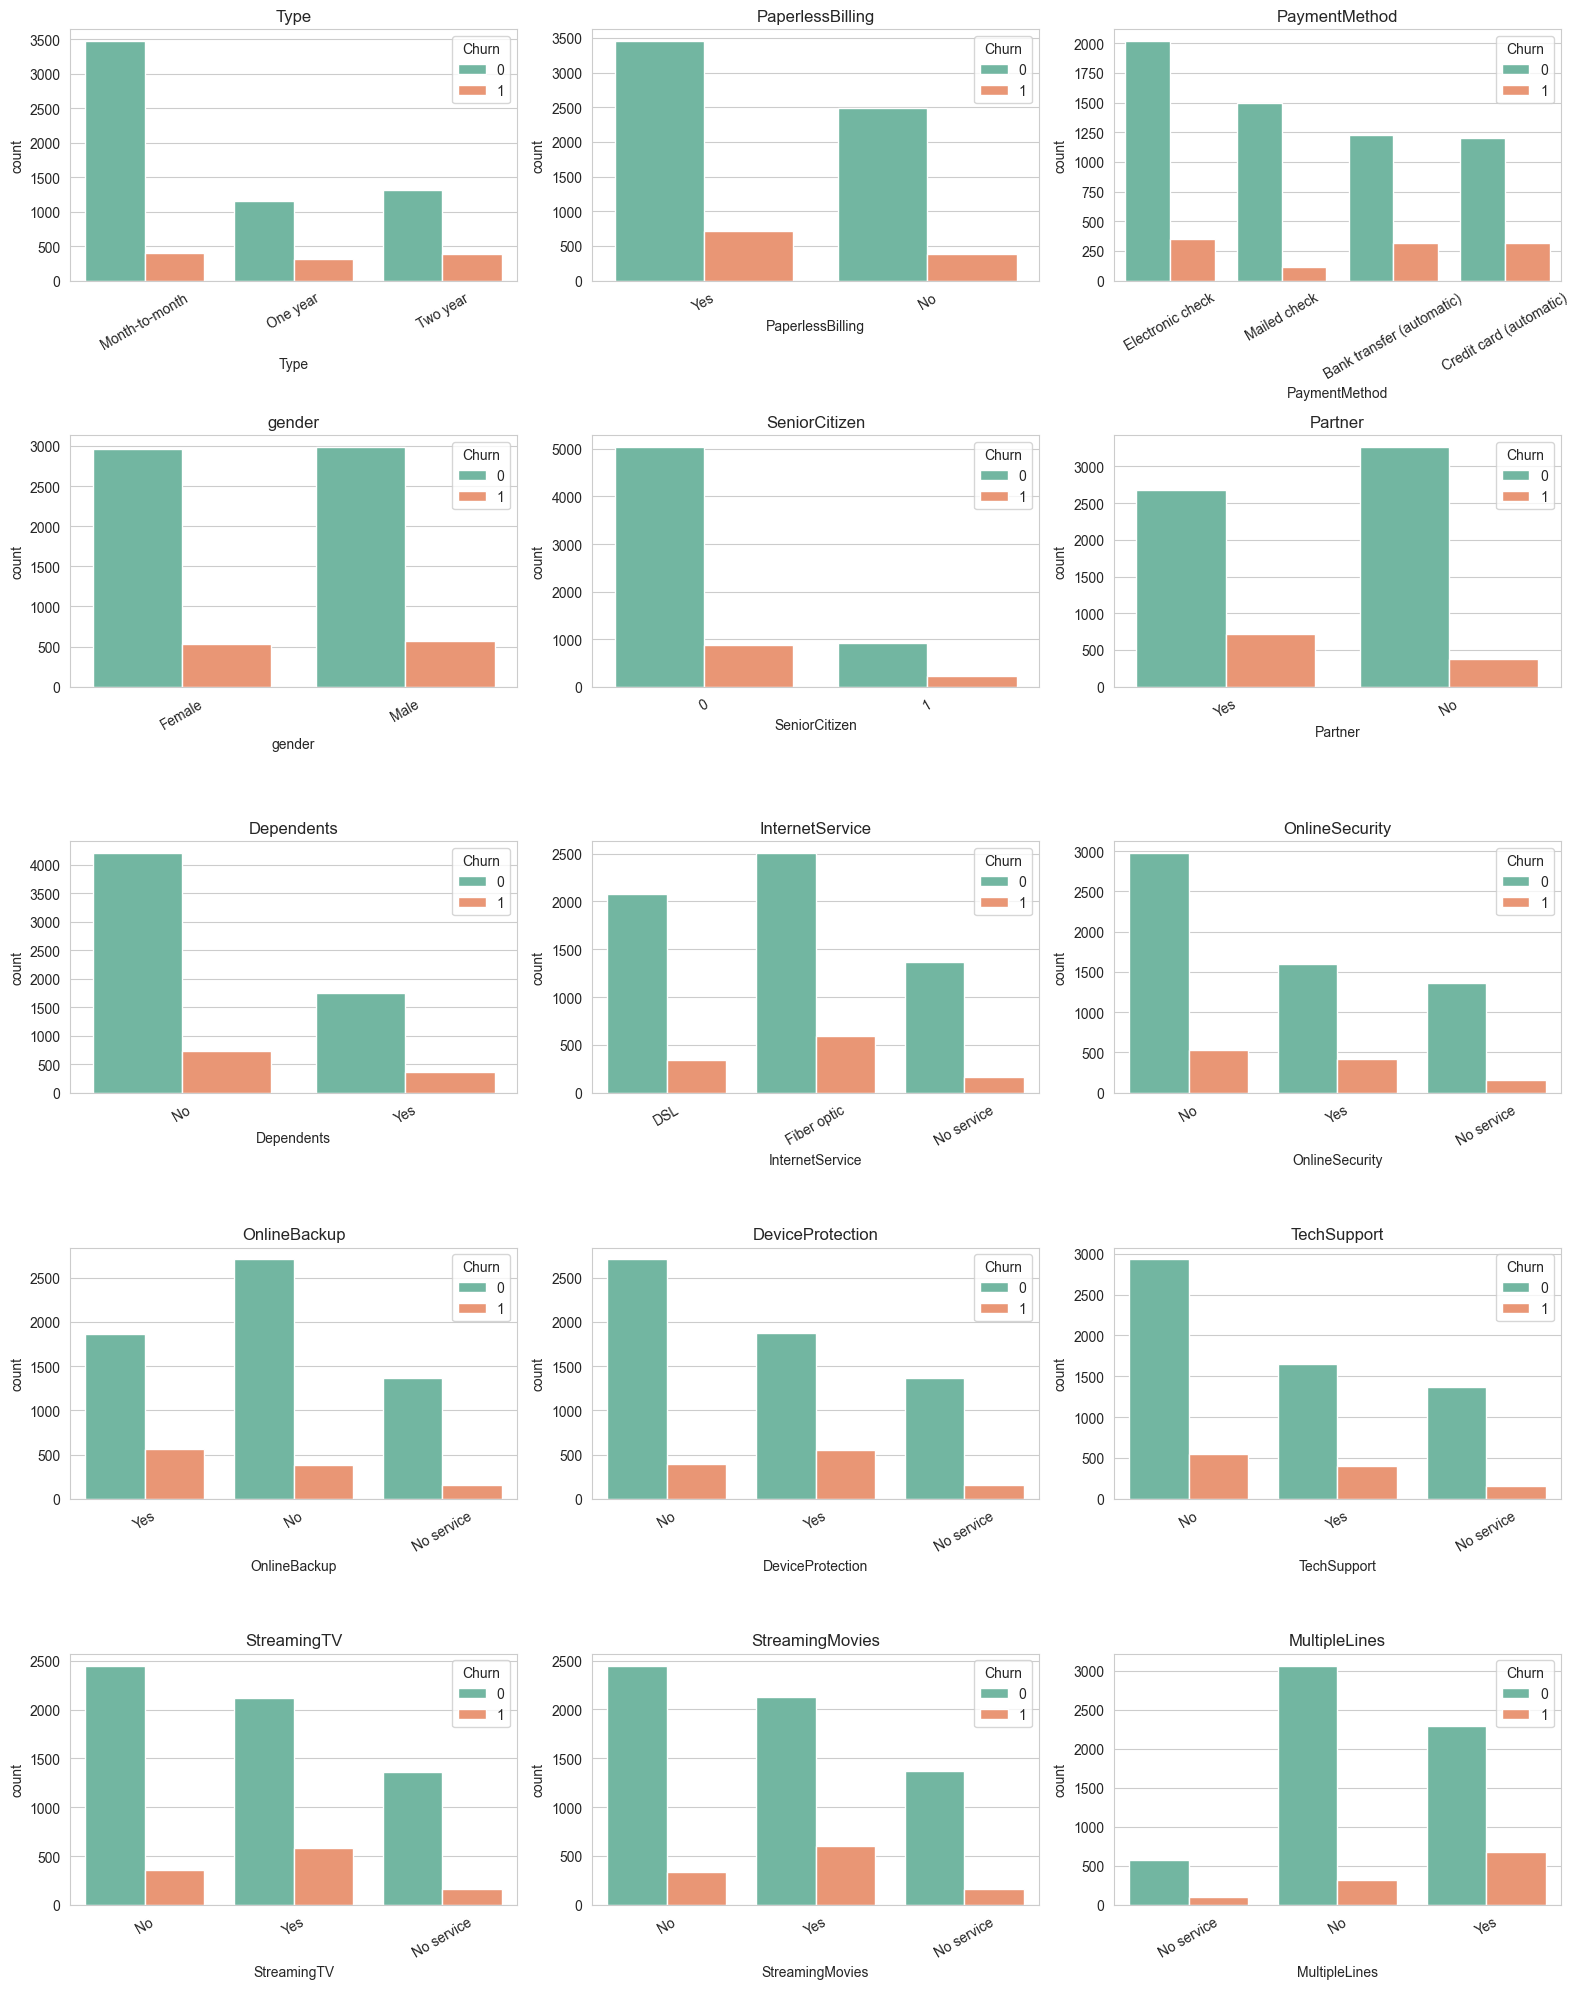

In [26]:
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax, palette='Set2')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Исследовательский анализ показал, что распределения признаков соответствуют предметной области. Для ряда признаков наблюдаются различия между ушедшими и оставшимися клиентами, что говорит об их потенциальной информативности для модели.

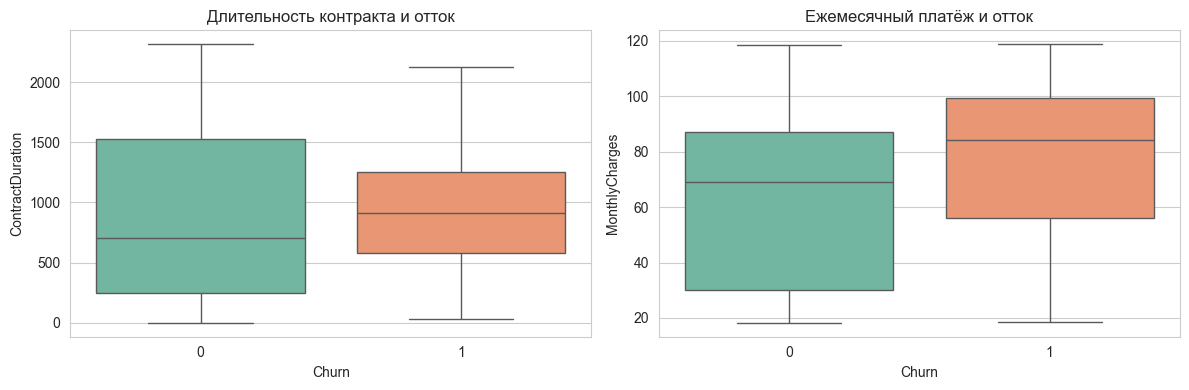

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Churn', y='ContractDuration', ax=axes[0], palette='Set2')
axes[0].set_title('Длительность контракта и отток')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2')
axes[1].set_title('Ежемесячный платёж и отток')
plt.tight_layout()
plt.show()

Ушедшие клиенты в среднем имели заметно более короткую длительность контракта и более высокий ежемесячный платёж, чем оставшиеся - оба признака выглядят перспективными для модели.

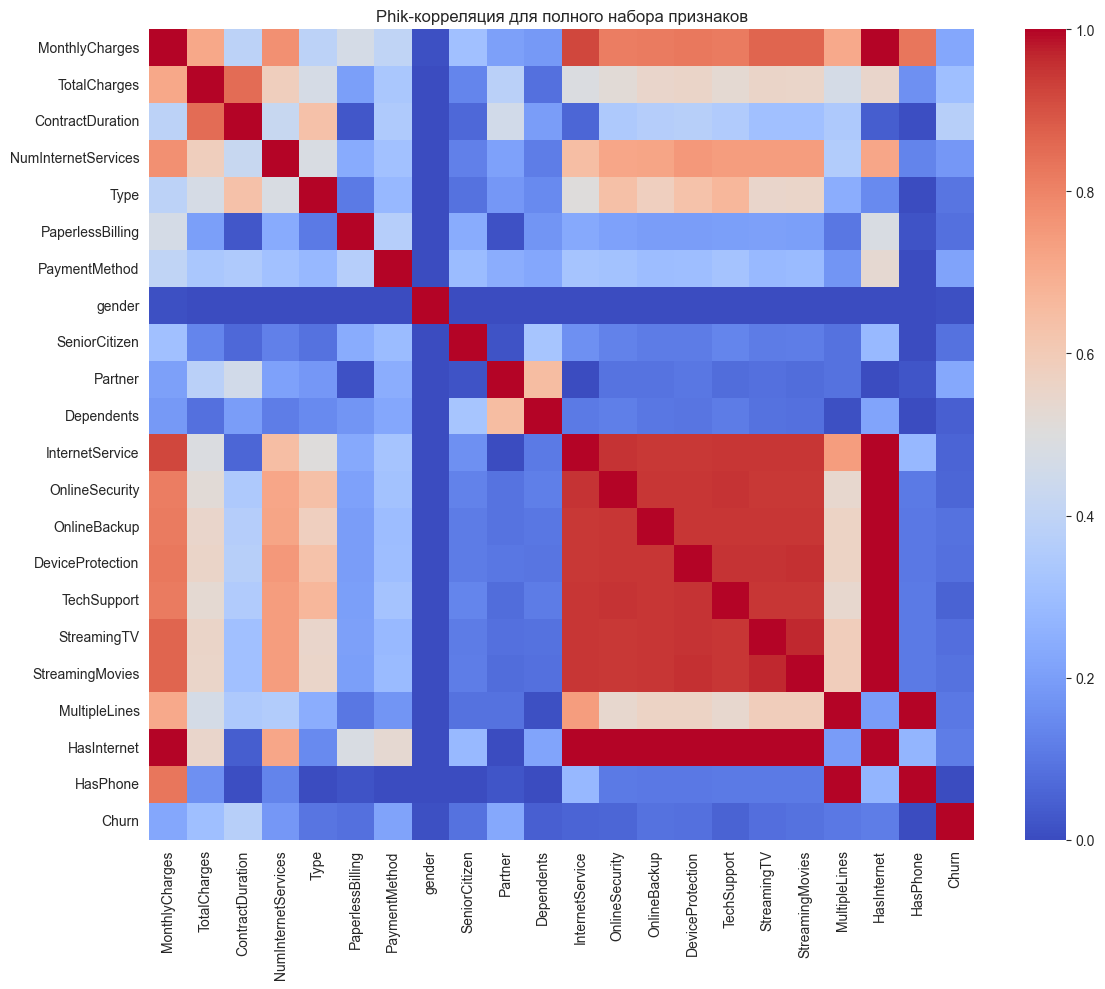

ContractDuration       0.374569
TotalCharges           0.302890
Partner                0.226688
MonthlyCharges         0.225925
PaymentMethod          0.214832
NumInternetServices    0.182556
HasInternet            0.114593
MultipleLines          0.105101
Type                   0.094015
OnlineBackup           0.089704
StreamingMovies        0.086577
SeniorCitizen          0.086159
DeviceProtection       0.085608
PaperlessBilling       0.083398
StreamingTV            0.078545
OnlineSecurity         0.058659
InternetService        0.056621
TechSupport            0.051537
Dependents             0.046871
gender                 0.008581
HasPhone               0.000000
Name: Churn, dtype: float64

In [28]:
cols_for_corr = num_cols + cat_cols + ['HasInternet', 'HasPhone', 'Churn']
phik_matrix = df[cols_for_corr].phik_matrix(interval_cols=num_cols)

plt.figure(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Phik-корреляция для полного набора признаков')
plt.tight_layout()
plt.show()

phik_matrix['Churn'].drop('Churn').sort_values(ascending=False)

**Вывод**

Phik-корреляция, рассчитанная для полного набора признаков (числовых, бинарных и категориальных), показала, что сильнее всего с оттоком связаны `ContractDuration`, `TotalCharges`, `Partner`, `MonthlyCharges` и `PaymentMethod` - это согласуется с наблюдениями из EDA. Большинство категориальных признаков (услуги интернета, тип подключения, наличие зависимых) показывают слабую или умеренную связь с оттоком.

Среди числовых признаков заметна сильная связь `TotalCharges` с `ContractDuration` (phik = 0.85) и с `MonthlyCharges` (phik = 0.71) - это ожидаемо, так как `TotalCharges` фактически является их производной. Поэтому при обучении модели `TotalCharges` стоит исключить, чтобы не дублировать информацию и не усиливать переобучение. Между остальными признаками сильной мультиколлинеарности не наблюдается.

## 5. Подготовка данных для обучения

Признаки `BeginDate`, `EndDate` и `TotalCharges` не используем при обучении: первые два - даты, по условию задачи не являются признаком (задача не временного ряда) и одновременно являются источником утечки целевого признака через `ContractDuration`; `TotalCharges` сильно коррелирован с `MonthlyCharges` и `ContractDuration` и фактически их производная. `customerID` - идентификатор, не несущий информации.

In [29]:
drop_cols = ['customerID', 'BeginDate', 'EndDate', 'TotalCharges', 'Churn']
feature_cols = [col for col in df.columns if col not in drop_cols]

X = df[feature_cols]
y = df['Churn']

numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col]) and col != 'SeniorCitizen']
categorical_features = [col for col in feature_cols if col not in numeric_features]

print('Категориальные признаки:', categorical_features)
print('Числовые признаки:', numeric_features)

Категориальные признаки: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
Числовые признаки: ['MonthlyCharges', 'ContractDuration', 'HasInternet', 'HasPhone', 'NumInternetServices']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.mean().round(3), y_test.mean().round(3))

(5282, 20) (1761, 20)
0.156 0.156


Выборки разделены со стратификацией по целевому признаку, чтобы доля оттока в train и test совпадала. Для решающего дерева, случайного леса и нейронной сети нужны числовые признаки - используем `ColumnTransformer` с `OneHotEncoder` для категорий и `StandardScaler` для числовых столбцов. CatBoost умеет работать с категориальными признаками напрямую, поэтому для него подготовим отдельные выборки без кодирования, лишь приведя категориальные столбцы к строковому типу.

In [31]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features),
])

cat_feature_idx = tuple(X_train.columns.get_loc(col) for col in categorical_features)
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()
for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

## 6. Обучение моделей

Рассмотрим три класса моделей: дерево решений/случайный лес, бустинг (CatBoost) и нейронную сеть (`MLPClassifier`). Лучшую модель будем выбирать по среднему ROC-AUC на кросс-валидации (5 фолдов со стратификацией).

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

In [33]:
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)),
])
dummy_scores = cross_val_score(dummy_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'DummyClassifier ROC-AUC (CV): {dummy_scores.mean():.3f}')
results.append({'model': 'DummyClassifier', 'roc_auc_cv': dummy_scores.mean(), 'params': {}})

DummyClassifier ROC-AUC (CV): 0.500


### 6.1 Дерево решений и случайный лес

In [34]:
tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

tree_params = {
    'model__max_depth': [4, 6, 8, 10, 12],
    'model__min_samples_leaf': [1, 5, 10, 20],
}

tree_search = GridSearchCV(tree_pipe, tree_params, scoring='roc_auc', cv=cv, n_jobs=-1)
tree_search.fit(X_train, y_train)

print('Лучшие параметры:', tree_search.best_params_)
print(f'ROC-AUC (CV): {tree_search.best_score_:.3f}')
results.append({'model': 'DecisionTree', 'roc_auc_cv': tree_search.best_score_, 'params': tree_search.best_params_})

Лучшие параметры: {'model__max_depth': 6, 'model__min_samples_leaf': 1}
ROC-AUC (CV): 0.793


In [35]:
forest_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE)),
])

forest_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [6, 8, 10, None],
    'model__min_samples_leaf': [1, 5, 10],
}

forest_search = RandomizedSearchCV(
    forest_pipe, forest_params, scoring='roc_auc', cv=cv,
    n_iter=15, random_state=RANDOM_STATE, n_jobs=-1,
)
forest_search.fit(X_train, y_train)

print('Лучшие параметры:', forest_search.best_params_)
print(f'ROC-AUC (CV): {forest_search.best_score_:.3f}')
results.append({'model': 'RandomForest', 'roc_auc_cv': forest_search.best_score_, 'params': forest_search.best_params_})

Лучшие параметры: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 10}
ROC-AUC (CV): 0.814


### 6.2 Бустинг - CatBoost

In [36]:
cb_params = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 7],
}

cb_base = CatBoostClassifier(
    iterations=300, random_state=RANDOM_STATE, cat_features=cat_feature_idx, verbose=False,
)

cb_search = RandomizedSearchCV(
    cb_base, cb_params, scoring='roc_auc', cv=cv,
    n_iter=10, random_state=RANDOM_STATE, n_jobs=-1,
)
cb_search.fit(X_train_cb, y_train)

print('Лучшие параметры:', cb_search.best_params_)
print(f'ROC-AUC (CV): {cb_search.best_score_:.3f}')
results.append({'model': 'CatBoost', 'roc_auc_cv': cb_search.best_score_, 'params': cb_search.best_params_})

Лучшие параметры: {'learning_rate': 0.2, 'l2_leaf_reg': 1, 'depth': 6}
ROC-AUC (CV): 0.907


### 6.3 Нейронная сеть

In [37]:
mlp_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(random_state=RANDOM_STATE, max_iter=500, early_stopping=True)),
])

mlp_params = {
    'model__hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'model__alpha': [0.0001, 0.001, 0.01],
}

mlp_search = GridSearchCV(mlp_pipe, mlp_params, scoring='roc_auc', cv=cv, n_jobs=-1)
mlp_search.fit(X_train, y_train)

print('Лучшие параметры:', mlp_search.best_params_)
print(f'ROC-AUC (CV): {mlp_search.best_score_:.3f}')
results.append({'model': 'MLPClassifier', 'roc_auc_cv': mlp_search.best_score_, 'params': mlp_search.best_params_})

Лучшие параметры: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64)}
ROC-AUC (CV): 0.819


In [38]:
results_df = pd.DataFrame(results).sort_values('roc_auc_cv', ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, 'model']
print(f'Лучшая модель по ROC-AUC на кросс-валидации: {best_model_name}')

,model,roc_auc_cv,params
0,CatBoost,0.906804,"{'learning_rate': 0.2, 'l2_leaf_reg': 1, 'dept..."
1,MLPClassifier,0.819064,"{'model__alpha': 0.0001, 'model__hidden_layer_..."
2,RandomForest,0.814088,"{'model__n_estimators': 200, 'model__min_sampl..."
3,DecisionTree,0.792879,"{'model__max_depth': 6, 'model__min_samples_le..."
4,DummyClassifier,0.500000,{}


Лучшая модель по ROC-AUC на кросс-валидации: CatBoost


**Вывод** 

Все обученные модели заметно превосходят константный прогноз (`DummyClassifier`), что подтверждает наличие предсказательной силы в признаках. Лучший результат на кросс-валидации показывает модель, выбранная в `best_model_name` - её и проверим на тестовой выборке.

## 7. Тестирование модели и демонстрация её работы

In [39]:
search_map = {
    'DecisionTree': (tree_search, X_test, 'sklearn'),
    'RandomForest': (forest_search, X_test, 'sklearn'),
    'CatBoost': (cb_search, X_test_cb, 'catboost'),
    'MLPClassifier': (mlp_search, X_test, 'sklearn'),
}

best_search, X_test_best, best_kind = search_map[best_model_name]
best_model = best_search.best_estimator_

y_pred_proba = best_model.predict_proba(X_test_best)[:, 1]
y_pred = best_model.predict(X_test_best)

test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_accuracy = accuracy_score(y_test, y_pred)

print(f'ROC-AUC на тесте: {test_roc_auc:.3f}')
print(f'Accuracy на тесте: {test_accuracy:.3f}')

ROC-AUC на тесте: 0.913
Accuracy на тесте: 0.919


Лучшая модель успешно прошла проверку на тестовой выборке. ROC-AUC 0.913 показывает хорошую способность модели разделять клиентов, склонных и не склонных к оттоку.

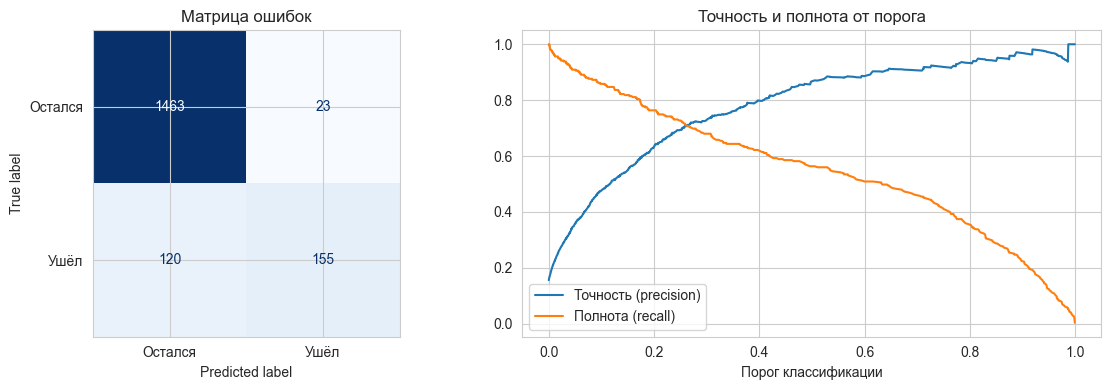

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Остался', 'Ушёл']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Матрица ошибок')

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(thresholds, precision[:-1], label='Точность (precision)')
axes[1].plot(thresholds, recall[:-1], label='Полнота (recall)')
axes[1].set_xlabel('Порог классификации')
axes[1].legend()
axes[1].set_title('Точность и полнота от порога')

plt.tight_layout()
plt.show()

Матрица ошибок показывает, что модель корректно классифицирует большую часть клиентов. Кривая Precision-Recall подтверждает хорошее соотношение полноты и точности.

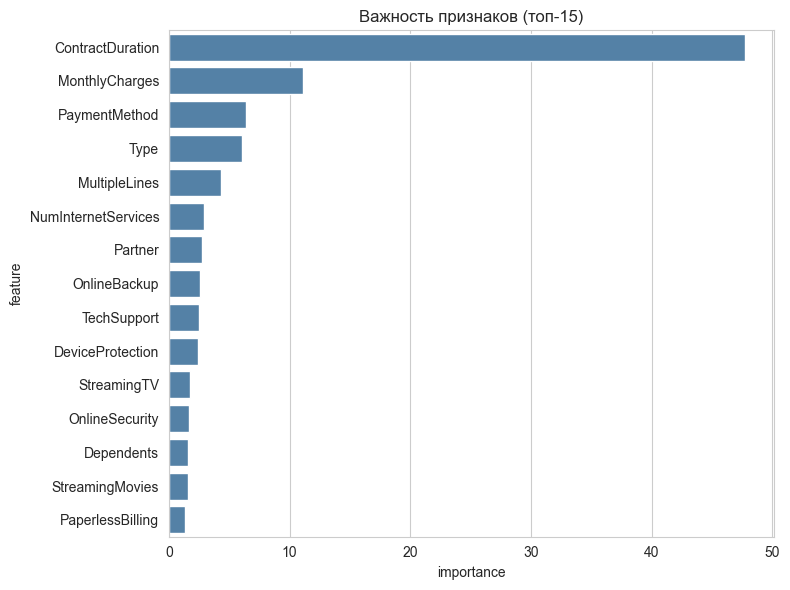

In [41]:
if best_kind == 'catboost':
    importances = best_model.get_feature_importance()
    feature_names = X_test_best.columns
else:
    feature_names = preprocessor.get_feature_names_out()
    importances = permutation_importance(
        best_model, X_test_best, y_test, scoring='roc_auc', n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
    ).importances_mean

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, y='feature', x='importance', color='steelblue')
plt.title('Важность признаков (топ-15)')
plt.tight_layout()
plt.show()

**Вывод**

Наибольший вклад в прогноз вносит длительность обслуживания (ContractDuration) — она заметно опережает по важности все остальные признаки. Далее следуют ежемесячный платёж (MonthlyCharges), способ оплаты и тип договора. Это соответствует логике предметной области: чем меньше клиент пользуется услугами и чем выше его ежемесячные расходы, тем выше риск оттока.

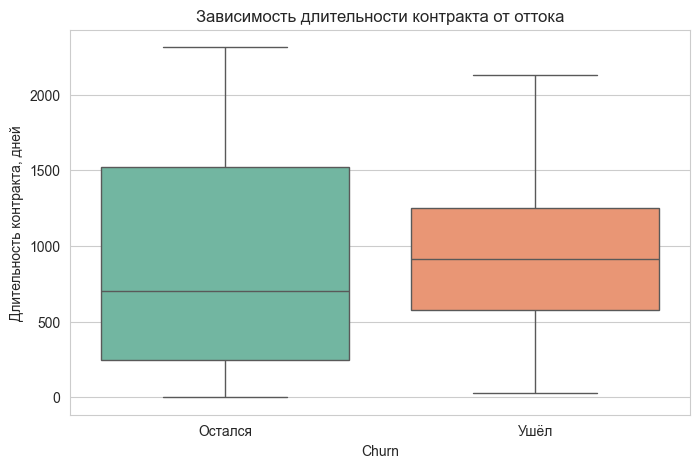

In [42]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='ContractDuration', palette='Set2')
plt.xticks([0, 1], ['Остался', 'Ушёл'])
plt.title('Зависимость длительности контракта от оттока')
plt.ylabel('Длительность контракта, дней')
plt.show()

Клиенты с меньшей длительностью обслуживания чаще попадают в группу оттока. Это согласуется с результатами анализа важности признаков и указывает на повышенный риск ухода в первые месяцы после подключения.

## 8. Общий вывод

В ходе выполнения проекта были загружены и объединены данные из нескольких таблиц, содержащих информацию о договорах, персональных данных клиентов и подключенных услугах. Для подготовки данных к обучению были приведены типы признаков, обработаны пропуски, сформирован целевой признак и созданы дополнительные признаки, отражающие длительность действия договора, наличие интернета и количество подключенных интернет-услуг.

После проведения исследовательского анализа были изучены распределения признаков, их взаимосвязь с целевой переменной и выполнен корреляционный анализ. Исследование показало, что ряд признаков связан с вероятностью оттока клиентов, поэтому они могут быть полезны при построении модели.

Для решения задачи были рассмотрены несколько моделей машинного обучения: Decision Tree, Random Forest, MLP и CatBoost. Лучшее качество на кросс-валидации показала модель CatBoost, после чего для нее был выполнен подбор гиперпараметров (глубина дерева, learning rate, l2-регуляризация) с помощью RandomizedSearchCV.

На тестовой выборке лучшая модель достигла следующих результатов:

* ROC-AUC = **0.913**;
* Accuracy = **0.919**.

Полученный ROC-AUC 0.913 свидетельствует о хорошем качестве ранжирования клиентов по риску оттока.

Анализ важности признаков показал, что наибольшее влияние на прогноз оказывают характеристики договора, длительность обслуживания клиента, стоимость услуг и параметры подключенных сервисов. Дополнительное исследование подтвердило, что вероятность ухода клиентов зависит от этих факторов.

Полученную модель можно использовать для выявления клиентов с высоким риском оттока и последующего формирования для них персональных предложений. Это позволит оператору связи своевременно принимать меры по удержанию клиентов, снижая уровень оттока и повышая эффективность программ лояльности.

Качество модели в дальнейшем можно повысить, добавив данные об истории обращений в техподдержку, динамике использования трафика и истории платежей (просрочки) - такие признаки могут оказаться более сильными предикторами оттока, чем статические характеристики договора. Также стоит попробовать другие модели градиентного бустинга (LightGBM, XGBoost) и более глубокий перебор гиперпараметров, например с помощью Optuna.

С точки зрения бизнеса наибольший риск оттока сосредоточен среди клиентов с помесячной оплатой, оплатой через Electronic check и подключением через Fiber optic без дополнительных услуг безопасности - именно на этот сегмент стоит направить удерживающие предложения в первую очередь. Отдельное внимание нужно уделить новым клиентам в первые месяцы обслуживания, так как риск оттока в этот период максимален, а также стимулировать переход на длительные тарифные планы и подключение дополнительных услуг (антивирус, техподдержка), которые коррелируют с более низким оттоком.
